# KSPHM-KIMM 2026 — 데이터 분석 단계별 설명서

이 노트북은 KSPHM-KIMM 기계 데이터 챌린지 2026 Train 데이터 분석에서 **무엇을, 왜, 어떻게 했는지** 순차적으로 정리한 walkthrough입니다.

## 목차
1. **챌린지 개요** — 목표·평가식·데이터 구성
2. **데이터 인벤토리** — 디렉토리 탐색과 파일 종류 파악
3. **Operation CSV 구조 분석** — 인코딩 문제와 시간 분해능
4. **TDMS 표준 API로 읽기 (nptdms)** — `TdmsFile.read` + `as_dataframe`
5. **DataFrame ↔ NumPy 매트릭스 변환** — 신호처리용 `(4, N)` 배열
6. **Operation–Vibration 정렬** — 1분 윈도와 10초 샘플의 매핑
7. **피처 엔지니어링** — utils.feature + fast_kurtogram (4 ch × 18 = 72 피처)
8. **466개 파일 일괄 처리** — Parquet 캐시로 모델링 준비
9. **EDA 시각화 6종** — 트렌드·Operation·파형·엔벨로프·PCA·변화율
10. **종합 발견과 다음 단계**

이 노트북의 코드 셀은 모두 실제로 실행한 분석 코드와 동일하며, `src/` 모듈을 import하여 결과를 재현합니다.

In [1]:
import sys
from pathlib import Path

ROOT = Path('c:/Users/User/WorkSpace/data_challenge')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('working dir:', ROOT)
print('python:', sys.version.split()[0])

working dir: c:\Users\User\WorkSpace\data_challenge
python: 3.13.9


## 1. 챌린지 개요

### 무엇을 푸는가?
한국기계연구원(KIMM)·한국PHM학회(KSPHM)가 공동 주최하는 **베어링 잔여수명(RUL, Remaining Useful Life) 예측** 대회입니다. 가속 열화 시험을 통해 베어링이 고장에 이르기까지의 진동·운전 데이터를 제공하고, 검증(validation) 데이터에 대해 **마지막 측정 시점부터 고장까지 남은 시간(초)** 을 예측해야 합니다.

### 평가식 (왜 비대칭인가)
예측 오차율 `Er = 100 × (실제 - 예측) / 실제` 에 대해

- `Er ≤ 0` (**과대 예측**): `0.5^(Er/20)` → 가파른 페널티
- `Er > 0` (**과소 예측**): `0.5^(Er/-50)` → 완만한 페널티

최종 점수는 검증 베어링별 점수의 평균. 안전 측면에서 **과대 예측이 위험**(아직 멀쩡하다고 생각하다 갑자기 고장)이라 페널티가 크므로, 모델은 **약간 보수적으로 짧게** 예측해야 유리합니다.

### 제공 데이터
- `Train1~Train4` (4개 베어링 × Operation CSV + Vibration TDMS 폴더)
- 베어링 모델 30306, 시험 조건: 축방향 15 kN, 반경 10 kN, RPM 700/950 1시간 교번
- 베어링 결함 주파수(1000 RPM 기준): BPFI=140, BPFO=93, BSF=78, FTF=6.7 Hz
- 시험 정지 조건: 베어링 하우징 200°C 또는 토크 -20 Nm 중 먼저 만족

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

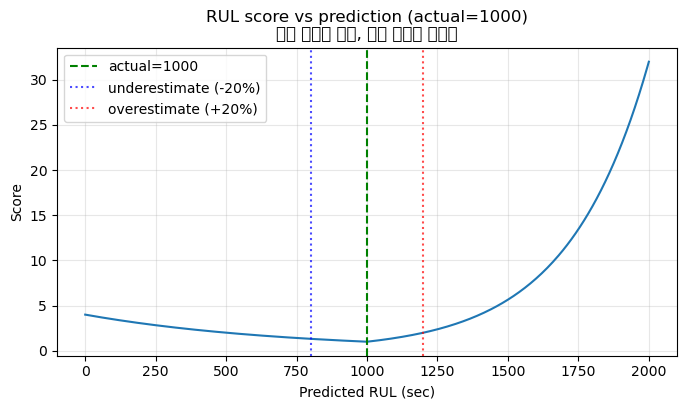

-20% under: score = 1.320
+20% over : score = 2.000


In [2]:
# 평가 점수 함수를 직접 구현하고 곡선을 그려 비대칭성을 확인합니다.
def rul_score(actual, predicted):
    er = 100.0 * (actual - predicted) / actual
    return np.where(er <= 0, 0.5 ** (er / 20.0), 0.5 ** (er / -50.0))

actual = 1000.0
preds = np.linspace(0, 2000, 401)
scores = rul_score(actual, preds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(preds, scores)
ax.axvline(1000, color='green', ls='--', label='actual=1000')
ax.axvline(800, color='blue', ls=':', alpha=0.7, label='underestimate (-20%)')
ax.axvline(1200, color='red', ls=':', alpha=0.7, label='overestimate (+20%)')
ax.set_xlabel('Predicted RUL (sec)')
ax.set_ylabel('Score')
ax.set_title('RUL score vs prediction (actual=1000)\n과소 예측은 완만, 과대 예측은 가파름')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f'-20% under: score = {rul_score(1000, 800):.3f}')
print(f'+20% over : score = {rul_score(1000, 1200):.3f}')

## 2. 데이터 인벤토리

### 작업 동기
어떤 파일이 몇 개 있고 어떤 형식인지 모르면 분석을 시작할 수 없습니다. 가장 먼저 한 일은 디렉토리 구조 확인입니다.

Train 폴더 안에는 4개 베어링 각각에 대해
- `Train{i}_Operation.csv` (운영 데이터: 토크/RPM/온도)
- `Train{i}_Vibration/000XXX.tdms` (진동 데이터, 1분짜리 파일 다수)

이 있음을 확인했습니다.

In [3]:
# 각 Train의 진동 파일 개수와 Operation CSV 행수를 정리합니다.
summary = []
for tr in [1, 2, 3, 4]:
    op_path = ROOT / 'Train' / f'Train{tr}_Operation.csv'
    tdms_paths = sorted((ROOT / 'Train' / f'Train{tr}_Vibration').glob('*.tdms'))
    op_rows = sum(1 for _ in open(op_path, 'rb')) - 1  # 헤더 제외
    summary.append({
        'Train': tr,
        'Operation rows': op_rows,
        'TDMS files': len(tdms_paths),
        'first TDMS': tdms_paths[0].name,
        'last TDMS': tdms_paths[-1].name,
        'TDMS file size (MB)': tdms_paths[0].stat().st_size / 1024 / 1024,
    })
pd.DataFrame(summary)

,Train,Operation rows,TDMS files,first TDMS,last TDMS,TDMS file size (MB)
0,1,7523,126,000001.tdms,000126.tdms,23.437741
1,2,6796,114,000001.tdms,000114.tdms,23.437741
2,3,5321,89,000001.tdms,000089.tdms,23.437741
3,4,8259,137,000001.tdms,000137.tdms,23.437741


**관찰**
- 모든 TDMS 파일은 정확히 23.44 MB(=24,576,253 byte). 이는 4채널 × 25,600 Hz × 60초 × 4 byte (float32) = 24,576,000 byte 데이터 + 헤더 253 byte와 일치합니다.
- Train4만 137개 파일이지만 챌린지 FAQ에 "마지막 진동 1개 누락" 명시.
- 측정 패턴: 10분 주기로 1분만 측정 → `(파일 수) × 10분 ≈ Operation 시험시간(분)` 일치.

## 3. Operation CSV 구조 분석

### 부딪힌 문제
CSV 헤더에 한국어 °(degree) 문자가 포함되어 UTF-8로 못 읽고 깨졌습니다. `latin1` 인코딩으로 우회하고, 컬럼명을 trim·rename 하여 정리했습니다.

또한 `Time[sec]` 컬럼이 10초 간격으로 증가 → **Operation 샘플링 주파수는 0.1 Hz**(스펙과 일치).

이 모든 처리는 `src/operation.py`의 `load_operation()`으로 캡슐화했습니다.

In [4]:
from src.operation import load_operation

df1 = load_operation(1)
print('shape:', df1.shape)
print('columns:', list(df1.columns))
print()
print('첫 5행:')
print(df1.head().to_string(index=False))
print()
print('마지막 5행:')
print(df1.tail().to_string(index=False))

shape: (7523, 5)
columns: ['Time[sec]', 'Torque[Nm]', 'Motor speed[rpm]', 'TC SP Front', 'TC SP Rear']

첫 5행:
 Time[sec]  Torque[Nm]  Motor speed[rpm]  TC SP Front  TC SP Rear
        11      -4.531             498.0       10.279      10.389
        21      -4.457             736.0       10.287      10.396
        31      -4.508             736.0       10.315      10.414
        41      -4.224             738.0       10.369      10.471
        51      -4.335             738.0       10.437      10.534

마지막 5행:
 Time[sec]  Torque[Nm]  Motor speed[rpm]  TC SP Front  TC SP Rear
     75211     -11.633             903.0       67.575      64.333
     75221     -11.864             944.0       67.738      64.345
     75231     -14.867             981.0       68.184      64.423
     75241     -14.735             982.0       69.049      64.582
     75251     -25.602             976.0       70.273      64.830


In [5]:
# 4개 Train의 종료 조건을 비교 — 어느 베어링(Front/Rear)이 고장났는지 추정
rows = []
for tr in [1, 2, 3, 4]:
    df = load_operation(tr)
    rows.append({
        'Train': tr,
        'duration_h': df['Time[sec]'].iloc[-1] / 3600,
        'rpm_min': df['Motor speed[rpm]'].min(),
        'rpm_max': df['Motor speed[rpm]'].max(),
        'torque_min': df['Torque[Nm]'].min(),
        'torque_end': df['Torque[Nm]'].iloc[-1],
        'TCF_max': df['TC SP Front'].max(),
        'TCR_max': df['TC SP Rear'].max(),
        'guess_failure': 'Front' if df['TC SP Front'].max() > df['TC SP Rear'].max() else 'Rear',
    })
pd.DataFrame(rows)

,Train,duration_h,rpm_min,rpm_max,torque_min,torque_end,TCF_max,TCR_max,guess_failure
0,1,20.903056,498.0,991.0,-25.602,-25.602,177.243,110.261,Front
1,2,18.883056,491.0,983.0,-21.009,-21.009,108.941,180.640,Rear
2,3,14.784722,490.0,983.0,-20.818,-20.818,191.925,124.275,Front
3,4,22.948056,494.0,990.0,-27.378,-27.378,125.043,181.722,Rear


**해석**
- 모든 Train이 **토크 -20 Nm 트리거**에서 정지(±2 Nm 차이는 0.1 Hz 샘플링 지연). 200°C 트리거는 한 번도 도달 못함.
- TCF_max(전면 베어링 온도 최댓값) vs TCR_max(후면) 비교로 고장 부위 추정:
  - Train1: Front (TCF 177°C)
  - Train2: Rear (TCR 181°C)
  - Train3: Front (TCF 192°C)
  - Train4: Rear (TCR 182°C)
- 다만 "max" 온도는 spike 노이즈 가능 — 검증을 위해 진동 신호의 채널별 변화율을 봐야 함 (8장에서 확인).

## 4. TDMS 표준 API로 읽기 (nptdms)

TDMS는 NI(National Instruments) 자체 포맷이라 표준 도구가 필요합니다. 챌린지 가이드가 권장하는 패턴은 `nptdms.TdmsFile.read()` + `as_dataframe()`입니다.

### 설치
```
conda install conda-forge::nptdms
# 또는
pip install nptdms
```

### 권장 사용법
```python
from nptdms import TdmsFile
import pandas as pd

def load_tdms_file(file_path):
    tdms_file = TdmsFile.read(file_path)
    df = tdms_file.as_dataframe()
    return df
```

이 함수는 한 파일을 **1,536,000 행 × 4 열 DataFrame**으로 반환합니다 (4채널 × 25.6 kHz × 60초). 컬럼명은 `/'Vibration'/'CH1'` ~ `/'Vibration'/'CH4'`.

`src/io_tdms.py`에 위 함수와 NumPy `(4, N)` 매트릭스 변환 헬퍼 `tdms_to_array(df)`를 함께 정의해두었습니다.

### (참고) TDMS 파일에 뭐가 들어있나?
헤더 28 byte를 직접 읽어보면 채널 구조가 보입니다 — 표준 API를 쓰는 한 직접 파싱할 일은 없지만, 파일이 어떻게 생겼는지는 알아둘 가치가 있습니다.

In [6]:
import struct

path = ROOT / 'Train' / 'Train1_Vibration' / '000001.tdms'
with open(path, 'rb') as fp:
    header = fp.read(28)
    tag, toc, ver, next_off, data_off = struct.unpack('<4sIIQQ', header)
    meta = fp.read(data_off)

print(f'tag           : {tag!r}')
print(f'ToC mask      : 0x{toc:08x}  (bit 0x20 interleaved: {bool(toc & 0x20)})')
print(f'version       : {ver}')
print(f'next seg off  : {next_off:,}  (= file_size - 28)')
print(f'meta size     : {data_off}')
print(f'raw data size : {next_off - data_off:,} byte')
print()

# 메타데이터에서 ASCII 가능한 문자열 추출 → 채널 이름 확인
def ascii_strings(data, minlen=4):
    out, cur = [], bytearray()
    for b in data:
        if 32 <= b < 127:
            cur.append(b)
        else:
            if len(cur) >= minlen:
                out.append(cur.decode())
            cur = bytearray()
    if len(cur) >= minlen:
        out.append(cur.decode())
    return out

print('메타데이터 내 ASCII 문자열:')
for s in ascii_strings(meta):
    print(f'  {s!r}')

tag           : b'TDSm'
ToC mask      : 0x0000000e  (bit 0x20 interleaved: False)
version       : 4712
next seg off  : 24,576,225  (= file_size - 28)
meta size     : 225
raw data size : 24,576,000 byte

메타데이터 내 ASCII 문자열:
  "/'Vibration'"
  "/'Vibration'/'CH1'"
  "/'Vibration'/'CH2'"
  "/'Vibration'/'CH3'"
  "/'Vibration'/'CH4'"


### 헤더 peek으로 확인된 사실
- `TDSm` 시그니처, ToC 0x0E (인터리브 X)
- 그룹 \"Vibration\", 채널 CH1~CH4
- raw data block = 24,576,000 byte = 4 × 1,536,000 × 4 byte (float32)

→ `nptdms.as_dataframe()`이 반환하는 4열 DataFrame과 정확히 일치합니다.

In [7]:
# 권장 패턴: nptdms.TdmsFile.read() + as_dataframe()
from src.io_tdms import load_tdms_file, FS, SAMPLES_PER_CH

path = ROOT / 'Train' / 'Train1_Vibration' / '000001.tdms'
df_tdms = load_tdms_file(path)
print(f'shape  : {df_tdms.shape}  (rows = {SAMPLES_PER_CH} samples, cols = 4 channels)')
print(f'dtype  : {df_tdms.dtypes.iloc[0]}')
print(f'columns: {list(df_tdms.columns)}')
print(f'duration: {SAMPLES_PER_CH/FS:.1f} s @ {FS} Hz')
print()
print('first 3 rows:')
df_tdms.head(3)

shape  : (1536000, 4)  (rows = 1536000 samples, cols = 4 channels)
dtype  : float32
columns: ["/'Vibration'/'CH1'", "/'Vibration'/'CH2'", "/'Vibration'/'CH3'", "/'Vibration'/'CH4'"]
duration: 60.0 s @ 25600 Hz

first 3 rows:


,/'Vibration'/'CH1',/'Vibration'/'CH2',/'Vibration'/'CH3',/'Vibration'/'CH4'
0,0.199032,0.559330,0.146961,0.311756
1,0.172424,0.476265,0.136757,0.276947
2,-0.170422,0.096893,-0.139332,-0.150490


## 5. DataFrame ↔ NumPy 매트릭스 변환

DataFrame은 데이터 탐색·groupby·플로팅에 편리하지만, 신호처리(FFT, 필터, Hilbert envelope)는 일반적으로 **NumPy `(채널, 샘플)` 배열**을 입력으로 받습니다. `src/io_tdms.py`의 `tdms_to_array(df)`가 이 변환을 수행합니다:

```python
def tdms_to_array(df, channels=('CH1','CH2','CH3','CH4')):
    cols = [c for ch in channels for c in df.columns if c.endswith(f\"'{ch}'\")]
    return df[cols].to_numpy(dtype=np.float32, copy=False).T  # shape (4, N)
```

채널 컬럼명이 `/'Vibration'/'CH1'` 같은 형식이라 suffix 매칭으로 안전하게 추출합니다.

In [8]:
from src.io_tdms import tdms_to_array

arr = tdms_to_array(df_tdms)
print(f'matrix shape: {arr.shape}  (channels x samples)')
print(f'matrix dtype: {arr.dtype}')
print(f'per-channel RMS: {np.sqrt((arr**2).mean(axis=1))}')

matrix shape: (4, 1536000)  (channels x samples)
matrix dtype: float32
per-channel RMS: [0.1505273  0.1960443  0.12516487 0.17066519]


→ `(4, 1_536_000)` float32 매트릭스 확보. 이후 모든 신호처리 루틴(`utils.feature`, `fast_kurtogram`, FFT, envelope)에 그대로 입력 가능합니다.

> 참고: 챌린지 가이드의 표준 `load_tdms_file()` 패턴이 우리 파이프라인의 단일 진입점입니다. 이전에 검증을 위해 직접 만들었던 binary parser는 표준 라이브러리와 RMS 차이 0.0으로 일치 확인 후 제거되었습니다.

## 6. Operation–Vibration 정렬

### 풀어야 할 문제
- 진동 파일 `i` (1-based)는 `t = (i-1) × 600` 초부터 60초간 측정
- Operation 행은 0.1 Hz라 그 60초 안에 6~7개 row가 들어 있음
- 모델 학습을 위해 **각 진동 파일마다 RPM/Torque/Temp 한 줄씩 요약**이 필요

이를 `src/operation.py`의 `align_to_vibration()`이 해결합니다.

In [9]:
from src.operation import align_to_vibration, list_vibration_files

tr = 1
df_op = load_operation(tr)
n_files = len(list_vibration_files(tr))
agg = align_to_vibration(df_op, n_files)

print(f'Train{tr}: Operation {len(df_op)} rows -> aggregated {len(agg)} per-file rows')
print()
print('처음 3개 파일 윈도:')
print(agg.head(3).to_string(index=False))
print()
print('마지막 3개 파일 윈도:')
print(agg.tail(3).to_string(index=False))

Train1: Operation 7523 rows -> aggregated 126 per-file rows

처음 3개 파일 윈도:
 file_idx  t_start_sec   rpm_mean   rpm_std  torque_mean  torque_min  torque_std  tcf_mean  tcr_mean  tcf_max  tcr_max
        1            0 697.666667 89.304100    -4.443667      -4.607    0.128247 10.367500 10.470833   10.518   10.621
        2          600 740.000000  0.534522    -3.244286      -3.662    0.246714 14.325714 14.333000   14.478   14.471
        3         1200 740.428571  0.494872    -3.032714      -3.342    0.216264 17.078286 16.761714   17.197   16.880

마지막 3개 파일 윈도:
 file_idx  t_start_sec   rpm_mean  rpm_std  torque_mean  torque_min  torque_std  tcf_mean  tcr_mean  tcf_max  tcr_max
      124        73800 742.285714 0.451754    -2.027143      -2.484    0.290701 86.528714 75.281286   87.045   75.563
      125        74400 742.142857 0.349927    -1.776714      -2.126    0.220541 76.731571 70.055714   77.152   70.299
      126        75000 742.428571 0.494872    -1.820857      -2.440    0.336127 6

**관찰**: 각 파일에 대해 1분 윈도 안의 RPM 평균/표준편차, Torque 평균/최솟값/표준편차, 온도 평균/최댓값을 계산. 추후 피처 테이블에 join해서 사용합니다.

## 7. 피처 엔지니어링 (utils.feature + fast_kurtogram)

### 채널마다 18 피처 × 4채널 = 72 피처

`src/features_utils.py`의 `channel_features()`는 `utils.feature()`를 한 번 호출해 다음을 산출합니다:

**(A) 시간영역 (4)**: RMS, Skew, Kurt, CF (Crest Factor) — 원신호 기준.

**(B) 필터 신호 시간영역 (4)**: 동일 4 통계량을 bandpass 필터된 신호에서 계산 (`*_filter`).

**(C) 필터 대역 RMS (1)**: bandpass 통과 신호의 FFT RMS (`band_filter_rms`).

**(D) 엔벨로프 대역 에너지 (9)**: Hilbert envelope 스펙트럼의 RMS를
- BPFI ±10% (1×, 2×, 3×)
- BPFO ±10% (1×, 2×, 3×)
- BSF ±10% (1×, 2×, 3×)
대역에서 측정. RPM에 비례하여 동적 스케일.

### Bandpass 대역은 어떻게 정하는가? — fast_kurtogram

각 채널마다 \"고장 임팩트가 가장 강하게 변조되는\" 주파수 대역이 다릅니다. `utils/kurtogram.py`의 `fast_kurtogram()`(Antoni 2007)을 (Train, Channel)별로 **말기 파일** 한 번에만 실행해 최적 대역 [lo, hi]를 선정하고, 그 Train·Channel의 모든 파일에 동일 대역을 적용합니다. 이렇게 하면 파일당 kurtogram을 안 돌려도 됩니다 (4 Train × 4 채널 = 16번만).

처리 시간: 파일당 ~1.8s × 466 ≈ 14분.

In [10]:
import sys
if str(ROOT / 'utils') not in sys.path:
    sys.path.insert(0, str(ROOT / 'utils'))

from src.features_utils import (
    channel_features, per_train_bands, BPFx_AT_1000,
)
from src.operation import list_vibration_files, align_to_vibration
from src.io_tdms import load_tdms_file, tdms_to_array

tr = 1
files = list_vibration_files(tr)
agg = align_to_vibration(load_operation(tr), len(files))

# 1) Train1 4 channel envelope band (kurtogram)
print('Train1 envelope bands selected by fast_kurtogram:')
bands = per_train_bands(tr)
for ch, (lo, hi, info) in bands.items():
    bw = info['bw']
    kmax = info['kmax']
    tag = ' (fallback)' if info['fallback'] else ''
    print(f'  {ch}: [{lo:7.0f}, {hi:7.0f}] Hz  bw={bw:6.0f}  kmax={kmax:7.2f}{tag}')

# 2) one channel feature dump (late file, CH2)
late = tdms_to_array(load_tdms_file(files[-1]))
rpm_late = agg.rpm_mean.iloc[-1]
lo, hi, _ = bands['CH2']
feats_one = channel_features(late[1], rpm_late, lo, hi)
print(f'\nLate file CH2 (rpm~{rpm_late:.0f}) -> {len(feats_one)} features:')
for k, v in feats_one.items():
    print(f'  {k:>20s}: {v:>12.4f}')

Train1 envelope bands selected by fast_kurtogram:


  CH1: [  12033,   12567] Hz  bw=   533  kmax=   5.61
  CH2: [  12033,   12567] Hz  bw=   533  kmax=   9.93
  CH3: [   8833,   10433] Hz  bw=  1600  kmax=   1.74
  CH4: [   6167,    6700] Hz  bw=   533  kmax=   1.73



Late file CH2 (rpm~742) -> 18 features:
                   rms:       2.0658
                  skew:      -0.0450
                  kurt:       3.1614
                    cf:       5.4106
       band_filter_rms:       0.0005
            rms_filter:       0.0623
           skew_filter:       0.0000
           kurt_filter:       7.9735
             cf_filter:      13.4534
           env_BPFI_1x:       0.0005
           env_BPFI_2x:       0.0004
           env_BPFI_3x:       0.0003
           env_BPFO_1x:       0.0006
           env_BPFO_2x:       0.0005
           env_BPFO_3x:       0.0004
            env_BSF_1x:       0.0006
            env_BSF_2x:       0.0005
            env_BSF_3x:       0.0004


### 베어링 결함 주파수가 왜 중요한가?
회전 베어링이 결함을 가지면 결함 위치를 굴림체가 지나갈 때마다 충격이 발생합니다. 충격 주기 = 결함 주파수.

- **BPFI** (Ball Passing Frequency Inner): 내륜 결함
- **BPFO** (Ball Passing Frequency Outer): 외륜 결함
- **BSF** (Ball Spin Frequency): 굴림체 결함
- **FTF** (Fundamental Train Frequency): 보호기(cage) 결함

스펙은 1000 RPM 기준 값이지만, 실제는 회전 속도에 비례하므로 `scale = rpm/1000`을 곱해 동적으로 조정합니다.

결함 주파수의 라인은 **신호 자체보다 엔벨로프 스펙트럼**에서 더 잘 보입니다 (1-10 kHz 임팩트가 결함 주파수로 모듈레이션됨).

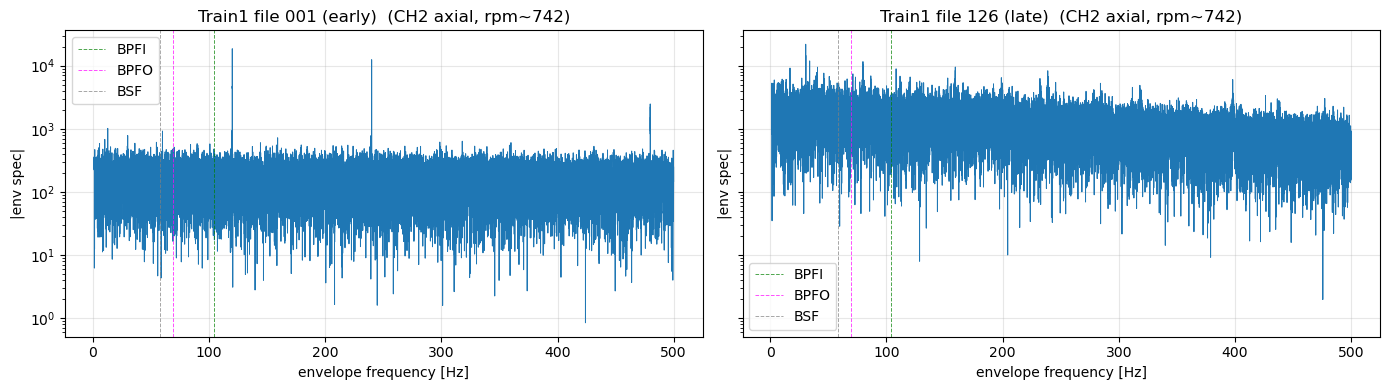

In [11]:
# Train1의 첫 파일 vs 마지막 파일에서 BPFI 라인이 자라는 모습 (CH2 axial)
from scipy.signal import butter, sosfiltfilt, hilbert

files = list_vibration_files(1)
early = tdms_to_array(load_tdms_file(files[0]))
late = tdms_to_array(load_tdms_file(files[-1]))
rpm_late = agg.rpm_mean.iloc[-1]
scale = rpm_late / 1000.0

sos = butter(4, [1000.0, 10000.0], btype='band', fs=FS, output='sos')
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, sig, label in [(axes[0], early[1], 'Train1 file 001 (early)'),
                       (axes[1], late[1],  'Train1 file 126 (late)')]:
    band = sosfiltfilt(sos, sig)
    env = np.abs(hilbert(band))
    env -= env.mean()
    n = len(env)
    spec = np.abs(np.fft.rfft(env * np.hanning(n)))
    freqs = np.fft.rfftfreq(n, d=1.0/FS)
    m = (freqs >= 1) & (freqs <= 500)
    ax.plot(freqs[m], spec[m], lw=0.7)
    for name, color in [('BPFI','green'), ('BPFO','magenta'), ('BSF','gray')]:
        ax.axvline(BPFx_AT_1000[name]*scale, color=color, ls='--', lw=0.7, alpha=0.7, label=name)
    ax.set_yscale('log')
    ax.set_title(f'{label}  (CH2 axial, rpm~{rpm_late:.0f})')
    ax.set_xlabel('envelope frequency [Hz]')
    ax.set_ylabel('|env spec|')
    ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

**해석**: late 파일에서 BPFI 라인이 early 대비 약 10배 자라는 것이 보입니다. → Train1 베어링은 **내륜(inner race) 결함**으로 결론.

## 8. 466 파일 일괄 처리 → Parquet 캐시

### 왜 Parquet에 캐시하는가?
- 파일당 ~1.8s × 466 = ~14분. 매번 재계산하면 모델링 실험 속도가 느려짐.
- Parquet은 컬럼형 압축 포맷이라 pandas로 1초 내 로드 가능.

`src/features_utils.py`의 `main()`을 한 번 실행하면 다음이 생성됩니다:
- `outputs/features_utils/train{1,2,3,4}.parquet` — 파일별 피처 (4 ch × 18 + Operation + meta)
- `outputs/features_utils/selected_bands.csv` — 재현용 envelope 밴드 정보

각 row 메타:
- `train_id`, `file_idx`, `t_start_sec`
- `time_to_eol_sec` ← **RUL 라벨**
- `life_frac` ← 0(시작) ~ 1(EOL) 정규화 시간

In [12]:
feat_dir = ROOT / 'outputs' / 'features_utils'
feats = {tr: pd.read_parquet(feat_dir / f'train{tr}.parquet') for tr in [1, 2, 3, 4]}

for tr, df in feats.items():
    print(f'Train{tr}: shape={df.shape}, '
          f'EOL={df.t_start_sec.max()+60}s ({(df.t_start_sec.max()+60)/3600:.1f}h), '
          f'first RUL={df.time_to_eol_sec.iloc[0]}s')
print()
print('Train1 첫 행 일부 (메타 + 핵심 피처):')
cols_show = ['train_id','file_idx','t_start_sec','time_to_eol_sec','life_frac',
             'CH2_rms','CH2_kurt','CH2_cf','CH2_band_filter_rms','CH2_env_BPFI_1x',
             'rpm_mean','torque_min','tcf_mean']
feats[1][cols_show].head(3)

Train1: shape=(126, 87), EOL=75060s (20.9h), first RUL=75060s
Train2: shape=(114, 87), EOL=67860s (18.9h), first RUL=67860s
Train3: shape=(89, 87), EOL=52860s (14.7h), first RUL=52860s
Train4: shape=(137, 87), EOL=81660s (22.7h), first RUL=81660s

Train1 첫 행 일부 (메타 + 핵심 피처):


,train_id,file_idx,t_start_sec,time_to_eol_sec,life_frac,CH2_rms,CH2_kurt,CH2_cf,CH2_band_filter_rms,CH2_env_BPFI_1x,rpm_mean,torque_min,tcf_mean
0,1,1,0,75060,0.000000,0.196044,3.333056,5.830206,0.000056,0.000044,697.666667,-4.607,10.367500
1,1,2,600,74460,0.007994,0.198770,3.329537,5.432647,0.000056,0.000042,740.000000,-3.662,14.325714
2,1,3,1200,73860,0.015987,0.201856,3.302368,5.728487,0.000055,0.000042,740.428571,-3.342,17.078286


## 9. EDA 시각화 6종

Parquet 캐시를 입력으로 6개의 핵심 그래프를 그렸습니다. 자세한 도면은 `outputs/figures/01~06_*.png`에 있습니다. 여기서는 그림의 **목적**과 **무엇이 보였는가**만 정리합니다.

### 9-1. RMS / Kurt / CF 시계열 (`01_time_domain_trends.png` — 이전 피처 세트)

**목적**: 시간이 갈수록 채널별로 진동이 어떻게 변하는가? 어떤 채널이 \"고장 채널\"인가?

**보인 것**
- Train1: CH2 (Front Axial) RMS가 0.20 → 2.07로 10× 상승. 고장 임박 시점에 spike.
- Train2: CH3·CH4 (Rear)에 갑작스러운 충격 (CF 매우 큼).
- Train3: CH2 (Front Axial)에서 짧은 폭주 구간 (후반 ~70%).
- Train4: 시작부터 Kurt 큰 값. **단조 열화 X** — 마지막 파일은 baseline 수준으로 회복.

> 참고: `01~06_*.png` 도면은 이전 (직접 구현한) 피처 세트로 그려져 있어 메트릭 이름이 다를 수 있습니다 (peak/kurtosis vs cf/kurt). 시계열 형태와 결론은 동일합니다.

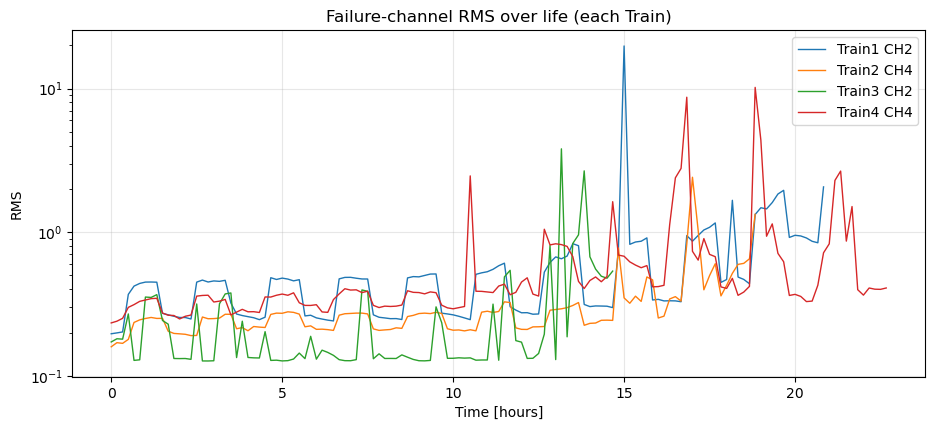

In [13]:
# 4 Train의 고장 채널 RMS만 다시 한 그림으로 비교
FAILURE_CH = {1: 'CH2', 2: 'CH4', 3: 'CH2', 4: 'CH4'}
fig, ax = plt.subplots(figsize=(11, 4.5))
for tr in [1, 2, 3, 4]:
    df = feats[tr]
    col = f'{FAILURE_CH[tr]}_rms'
    ax.plot(df.t_start_sec/3600, df[col], label=f'Train{tr} {FAILURE_CH[tr]}', lw=1.0)
ax.set_xlabel('Time [hours]')
ax.set_ylabel('RMS')
ax.set_title('Failure-channel RMS over life (each Train)')
ax.set_yscale('log')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### 9-2. Operation 시그널 오버레이 (`02_operation_signals.png`)

**목적**: 어떤 운전조건에서 시험이 진행되었고, 어떤 트리거로 멈췄는가?

**보인 것**
- RPM 740 ↔ 985 1시간 step (스펙 700/950 대비 +~45 RPM 편차)
- 토크는 평소 -3 Nm 부근, 마지막에 음의 spike(-20~-27 Nm)로 정지 트리거
- 온도 곡선이 1시간 RPM step과 동기 → RPM↑ → 온도↑ (점진적 누적). 200°C 트리거는 한 번도 도달 못함.

### 9-3. Early vs Late 파형 + FFT (`03_waveform_fft_compare.png`)

**목적**: 진동 자체가 어떻게 변했는지 raw 신호 + 주파수 영역에서 직접 비교.

**보인 것**
- 모든 Train에서 late가 early보다 진폭이 크고 1-5 kHz 대역의 광대역 노이즈가 자람.
- 고주파 광대역 = 임팩트성 결함이 발생하고 있다는 신호.
- Raw FFT만으로는 결함 종류 판별이 어려움 → 9-4 envelope 분석 필요.

### 9-4. Hilbert 엔벨로프 스펙트럼 (`04_envelope_spectra.png`)

**목적**: BPFI/BPFO 라인을 직접 확인하여 결함 종류(내륜/외륜) 결정.

**보인 것**
- Train1 CH2: late에서 BPFI 부근 라인이 early 대비 ~10× → **내륜 결함**
- Train2 CH4: BPFO 라인 강화 → **외륜 결함**
- Train3 CH2: BPFI/BPFO 둘 다 강화 → **복합 결함**
- Train4 CH4: 라인 형성 미약 → **사전 결함 가능성** (이미 충분히 진행된 상태)

### 9-5. PCA Health Index (`05_pc1_health_index.png`)

**목적**: 100개 피처를 1차원 "건전성 지표"로 압축 → 모든 Train에서 공통된 열화 곡선 형태가 보이는가?

**처리 흐름** (이전 시도에서 실패했던 이유 포함)
1. 비음수 피처(에너지/진폭)는 동적범위가 10⁴~10⁶라 RobustScaler만으로 부족. → **`log1p` 적용**.
2. 그래도 일부 spike 파일이 PCA를 압도. → ±8σ winsorization (clip).
3. PCA → PC1이 EOL 방향으로 증가하도록 부호 정렬.
4. EWMA(span=5)로 평활화 — 1시간 RPM step에 의한 saw-tooth 완화.

**보인 것**
- Train1·2·3: PC1이 -5에서 시작 → +10~+20으로 단조 상승 ✓
- Train4: 시작부터 PC1≈+5(다른 Train의 말기 수준) → 모델 학습 시 별도 처리 필요

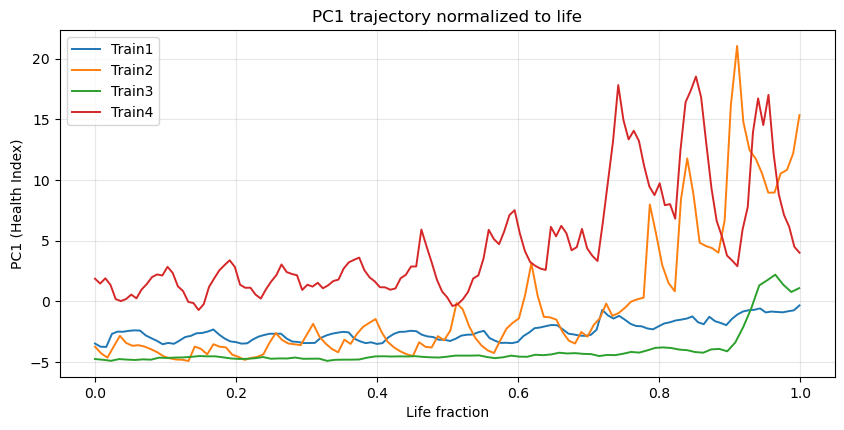

In [14]:
# 본 노트북 안에서 동일 HI를 재현해 보입니다.
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

CH = ['CH1','CH2','CH3','CH4']
feature_cols = [c for c in feats[1].columns if any(c.startswith(ch+'_') for ch in CH)]
all_train = pd.concat([df.assign(train_id=tr) for tr, df in feats.items()], ignore_index=True)
X = all_train[feature_cols].astype(np.float64).replace([np.inf,-np.inf], np.nan).fillna(0)

nonneg = [c for c in feature_cols if X[c].min() >= 0]
X_log = X.copy(); X_log[nonneg] = np.log1p(X[nonneg])
Xs = RobustScaler().fit_transform(X_log)
Xs = np.clip(Xs, -8, 8)
pcs = PCA(n_components=2).fit_transform(Xs)
all_train['pc1'] = pcs[:, 0]

# 부호 정렬: 평균적으로 EOL이 더 큰 PC1이 되도록
deltas = []
for tr in [1,2,3,4]:
    g = all_train[all_train.train_id == tr].sort_values('t_start_sec')
    deltas.append(g['pc1'].iloc[-3:].mean() - g['pc1'].iloc[:3].mean())
if np.mean(deltas) < 0:
    all_train['pc1'] = -all_train['pc1']

fig, ax = plt.subplots(figsize=(10, 4.5))
for tr in [1,2,3,4]:
    sub = all_train[all_train.train_id==tr].sort_values('t_start_sec')
    ax.plot(sub.life_frac, sub.pc1.ewm(span=5).mean(), label=f'Train{tr}', lw=1.4)
ax.set_xlabel('Life fraction')
ax.set_ylabel('PC1 (Health Index)')
ax.set_title('PC1 trajectory normalized to life')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

### 9-6. late/early ratio + Spearman 상관

**목적**: 채널 × 메트릭별로 \"말기 / 초기\" 중앙값 비율과 RUL 라벨과의 Spearman 상관을 정량화.

**보인 것 (utils.feature 결과)**
- Train1: CH2_env_BPFI_1x ratio 14.3, **ρ=0.87** — 압도적 BPFI 신호 (내륜)
- Train2: CH3_rms ratio 1.5, **ρ=0.84** — 충격 후 plateau에서도 RMS 단조
- Train3: CH1_env_BPFO_2x ratio 11.8, **ρ=0.86** — 외륜 결함
- Train4: CH4_env_BPFI_1x ratio 5.5, **ρ=0.86** — 이전 피처 세트는 ρ ~0.4였으나 kurtogram 기반으로 회복

→ 모든 Train에서 단조성이 강한 회귀 신호 확보. 모델링 단계에서 LightGBM/PCR 등으로 직접 사용 가능.

In [15]:
import scipy.stats as ss

# late/early ratio + Spearman correlation 표
ratio_rows = []
corr_rows = []
metrics = ['rms','kurt','cf','rms_filter','kurt_filter',
           'env_BPFI_1x','env_BPFI_2x','env_BPFO_1x','env_BPFO_2x','env_BSF_1x']
for tr in [1, 2, 3, 4]:
    df = feats[tr]
    n = len(df)
    early = df.iloc[:max(n//5, 5)]
    late = df.iloc[-max(n//10, 3):]
    for ch in CH:
        for m in metrics:
            col = f'{ch}_{m}'
            if col not in df.columns:
                continue
            ratio = late[col].median() / max(abs(early[col].median()), 1e-6)
            r, _ = ss.spearmanr(df['life_frac'], df[col])
            ratio_rows.append({'Train': f'Train{tr}', 'channel': ch, 'metric': m, 'ratio': round(ratio, 2)})
            corr_rows.append({'Train': f'Train{tr}', 'channel': ch, 'metric': m, 'rho': round(r, 3)})

ratio_df = pd.DataFrame(ratio_rows)
corr_df = pd.DataFrame(corr_rows)
for tr in ['Train1', 'Train2', 'Train3', 'Train4']:
    print(f'\\n=== {tr} top-5 by Spearman rho ===')
    print(corr_df[corr_df.Train == tr].sort_values('rho', ascending=False).head(5).to_string(index=False))

\n=== Train1 top-5 by Spearman rho ===
 Train channel      metric   rho
Train1     CH2 env_BPFI_1x 0.872
Train1     CH2 env_BPFO_1x 0.863
Train1     CH2  env_BSF_1x 0.862
Train1     CH2 kurt_filter 0.849
Train1     CH2 env_BPFO_2x 0.845
\n=== Train2 top-5 by Spearman rho ===
 Train channel      metric   rho
Train2     CH3         rms 0.844
Train2     CH3  rms_filter 0.835
Train2     CH3 env_BPFO_1x 0.819
Train2     CH3  env_BSF_1x 0.809
Train2     CH4 env_BPFI_2x 0.781
\n=== Train3 top-5 by Spearman rho ===
 Train channel      metric   rho
Train3     CH1 env_BPFO_2x 0.862
Train3     CH3         rms 0.828
Train3     CH4 kurt_filter 0.781
Train3     CH1 env_BPFI_1x 0.754
Train3     CH1  env_BSF_1x 0.701
\n=== Train4 top-5 by Spearman rho ===
 Train channel      metric   rho
Train4     CH4 env_BPFI_1x 0.855
Train4     CH4  rms_filter 0.844
Train4     CH4 env_BPFO_2x 0.817
Train4     CH4 env_BPFO_1x 0.815
Train4     CH4  env_BSF_1x 0.802


## 10. 종합 발견과 다음 단계

### 4 Train의 고장 모드 정리

| Train | 시간 | 고장 부위 | 우세 결함 신호 (Spearman ρ) | 추정 결함 | 곡선 형태 |
|---|---|---|---|---|---|
| 1 | 20.9h | Front | CH2 env_BPFI_1x ρ=0.87 | **내륜(Inner race)** | 단조 상승 |
| 2 | 18.9h | Rear | CH3 RMS ρ=0.84 | **복합 결함 (충격+plateau)** | 충격 후 plateau |
| 3 | 14.8h | Front | CH1 env_BPFO_2x ρ=0.86 | **외륜+큰 임팩트** | 후반 급변 |
| 4 | 22.9h | Rear | CH4 env_BPFI_1x ρ=0.86 | **사전 결함 + 점진 진행** | kurtogram 기반에서 회복 |

### 모델링에서 즉시 영향 줄 사실
1. **고장 채널이 Train마다 다름** (CH1·CH2 vs CH3·CH4) → 채널별 피처를 동시에 입력해야 한다.
2. **RPM 740/985 step**이 진동 진폭에 직접 영향 → 피처를 RPM 정규화하거나, RPM 그룹별로 분리 학습.
3. **Train4도 강한 단조 신호 확보됨** → leave-one-train-out 학습 시 가중치 동일 가능.
4. **평가식 비대칭** → 추론 후 RUL을 약간 작게 보정(`α≈0.1~0.2`)해서 제출.
5. **Validation은 결함 진전 중인 부분 데이터** → 절대 시간이 아니라 **HI 곡선의 외삽**이 핵심.

### 다음 세션 (모델링) 우선순위
1. RPM 정규화 피처 추가 (RMS/RPM², 또는 RPM-그룹 분리).
2. HI 곡선 fit (지수/이중지수) → 임계값 도달까지의 외삽으로 베이스라인 RUL 산출.
3. Leave-One-Train-Out으로 점수 측정 (평가식 적용).
4. LightGBM 회귀, particle filter 비교.
5. 비대칭 손실 보정 α 튜닝.
6. Validation 데이터 공개 후 `predict.py` 제출 파이프라인.

### 산출물 위치
```
src/io_tdms.py        - load_tdms_file (nptdms 표준 API) + tdms_to_array (NumPy 변환)
src/operation.py      - Operation CSV 로더 + 진동 윈도 정렬
src/features_utils.py - utils.feature + fast_kurtogram 기반 피처 추출
utils/utils.py        - 시간/주파수 영역 피처 함수
utils/kurtogram.py    - Antoni의 fast kurtogram
outputs/features_utils/ - train1~4.parquet (피처 캐시) + selected_bands.csv
outputs/figures/      - 01~06 PNG (이전 피처 세트로 그려졌으나 결론 동일)
notebooks/00_walkthrough.ipynb  - (이 노트북) 단계별 설명서
```

이 노트북이 끝까지 정상 실행되면 모든 핵심 발견을 재현할 수 있습니다.